In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
image_directory = "drive/MyDrive/Faulty_solar_panel"

Mounted at /content/drive/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from seaborn import heatmap
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight
!pip install visualkeras
from visualkeras import layered_view
from time import time
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 44.2 MB/s eta 0:00:00


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "training",
    seed = np.random.randint(1, 10000),
    image_size = (224, 224),
    batch_size = 32
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "validation",
    seed = np.random.randint(1, 10000),
    image_size = (224, 224),
    batch_size = 32
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [ ]:
# Forming the training labels array

y_train_true =  np.array([])
ct_arr = [0 for _ in range(len(class_names))]
for x, y in train_ds:
  y_train_true = np.concatenate([y_train_true, y.numpy()])
for i in y_train_true:
  ct_arr[int(np.round(i))] += 1
print("Number of elements per class: ", ct_arr)

Number of elements per class:  [169, 155, 148, 85, 50, 101]


In [ ]:
# Computing class weights

print("Correcting for class size imbalance...")
class_weights = dict(enumerate(class_weight.compute_class_weight(class_weight = 'balanced',
                                             classes = np.unique(y_train_true),
                                             y = y_train_true)))

Correcting for class size imbalance...


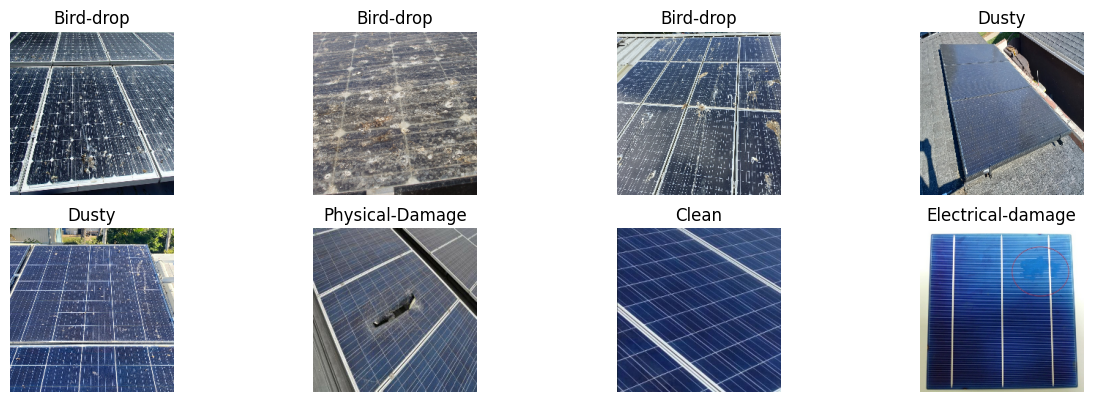

In [ ]:
plt.figure(figsize = (15, 20))
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape = (224, 224, 3),
    include_top=False,
    weights='imagenet'
    )
base_model.trainable = False
model = tf.keras.models.Sequential()
model.add(base_model)
del base_model
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(6, activation = tf.nn.softmax))

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       169,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,470 (4.23 MB)

 Trainable params: 169,350 (661.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

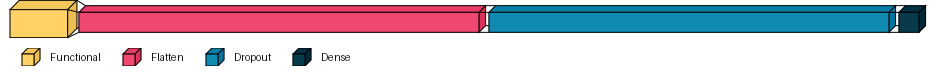

In [ ]:
layered_view(
    model,
    legend = True
    )

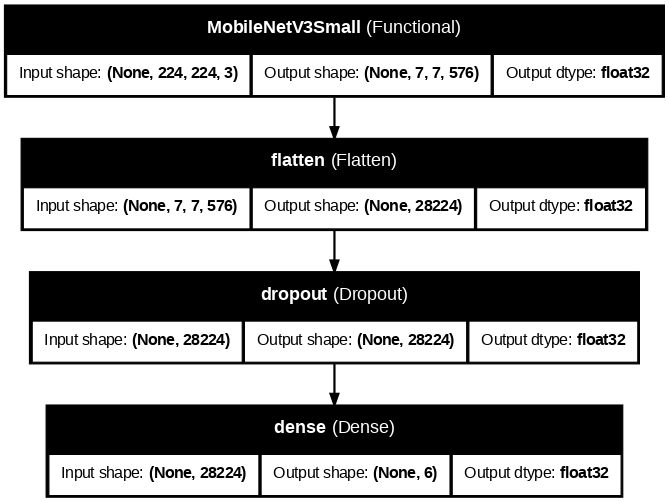

In [ ]:
tf.keras.utils.plot_model(
    model,
    to_file = 'model.png',
    show_shapes = True,
    show_layer_names = True,
    show_dtype = True,
    dpi = 80
    )

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

In [ ]:
start = time()
history = model.fit(
    train_ds,
    epochs = 10,
    validation_data = val_ds,
    class_weight = class_weights,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            patience = 5,
            restore_best_weights = True
            ),
        tf.keras.callbacks.ModelCheckpoint(
            "drive/MyDrive/current_model.keras",
            save_best_only=True,
            monitor="val_accuracy"
            )
        ]
    )
print(f"\nTotal time taken for training model: {(time()-start):.2f} seconds.")

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3806 - loss: 3.8359 - val_accuracy: 0.8418 - val_loss: 0.8405
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8951 - loss: 0.5351 - val_accuracy: 0.9266 - val_loss: 0.4958
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9458 - loss: 0.2082 - val_accuracy: 0.9379 - val_loss: 0.4531
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9749 - loss: 0.1245 - val_accuracy: 0.9435 - val_loss: 0.5203
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9860 - loss: 0.0710 - val_accuracy: 0.9435 - val_loss: 0.4960
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 958ms/step - accuracy: 0.9740 - loss: 0.1085 - val_accuracy: 0.9492 - val_loss: 0.5789
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 984ms/step - accuracy: 0.9869 - loss: 0.0987 - val_accuracy: 0.9435 - val_loss: 0.5531
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 999ms/step - accuracy: 0.9763 - loss: 0.1035 - val_accuracy: 0.9548 - 

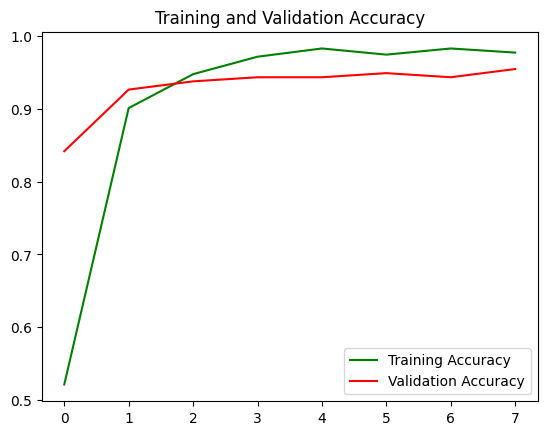

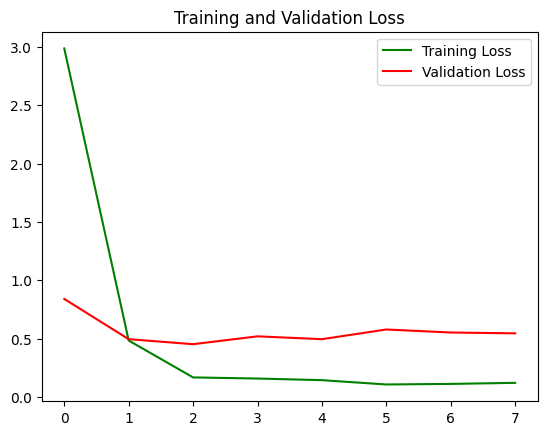

<Figure size 640x480 with 0 Axes>


Loss: 0.4531
Accuracy: 93.79%.


In [ ]:
get_ac = history.history['accuracy']
get_los = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
epochs = range(len(get_ac))

plt.plot(epochs, get_ac, 'g', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc=0)
plt.figure()

plt.plot(epochs, get_los, 'g', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc=0)
plt.figure()
plt.show()

loss, accuracy = model.evaluate(val_ds, verbose = 0)
print(f"\nLoss: {loss:.4f}\nAccuracy: {(accuracy*100):.2f}%.")

In [ ]:
y_pred = np.array([])
y_true =  np.array([])

for x, y in val_ds:
  y_pred = np.concatenate([y_pred, np.argmax(model.predict(x, verbose = 0), axis = -1)])
  y_true = np.concatenate([y_true, y.numpy()])

In [ ]:
print(f"Balanced Test Accuracy: {np.round(balanced_accuracy_score(y_true, y_pred)*100, 2)}%\n")
print(f"Detailed Metrics:\n{classification_report(y_true, y_pred)}")

Balanced Test Accuracy: 93.81%

Detailed Metrics:
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94        46
         1.0       0.89      0.94      0.92        36
         2.0       0.92      0.94      0.93        36
         3.0       0.94      0.94      0.94        16
         4.0       0.94      0.89      0.91        18
         5.0       0.96      1.00      0.98        25

    accuracy                           0.94       177
   macro avg       0.94      0.94      0.94       177
weighted avg       0.94      0.94      0.94       177



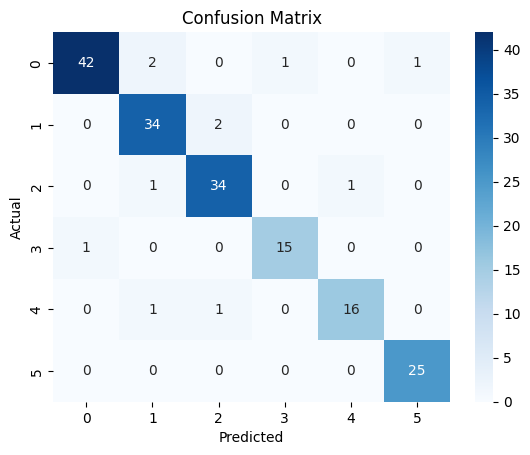

In [ ]:
heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()